In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.activation import ReLU
from src.convolution import Convolution2D

from src.utils import (
    load_image,
    show_image,
    plot_histogram
)

In [2]:
print("=" * 60)
print("CNN FROM SCRATCH")
print("05 - RELU ACTIVATION")
print("=" * 60)

CNN FROM SCRATCH
05 - RELU ACTIVATION


In [3]:
print("""
Without Activation:

Layer 1
↓
Layer 2
↓
Layer 3

is still only a linear transformation.

CNN needs Non-Linearity.

ReLU is the most popular activation
function in modern Deep Learning.
""")


Without Activation:

Layer 1
↓
Layer 2
↓
Layer 3

is still only a linear transformation.

CNN needs Non-Linearity.

ReLU is the most popular activation
function in modern Deep Learning.



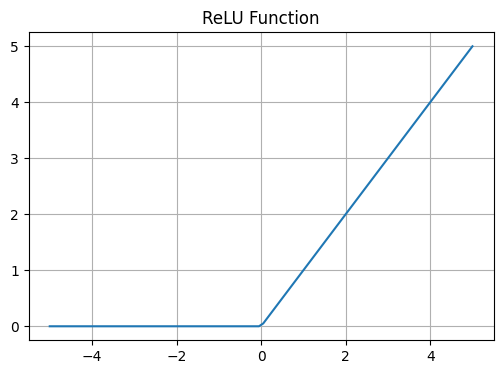

In [4]:
x = np.linspace(-5,5,100)

y = np.maximum(0,x)

plt.figure(figsize=(6,4))

plt.plot(x,y)

plt.title("ReLU Function")

plt.grid(True)

plt.show()

In [5]:
relu = ReLU()

sample = np.array([
    -5,
    -2,
    0,
    3,
    7
])

output = relu.forward(sample)

print("Input : ", sample)
print("Output:", output)

Input :  [-5 -2  0  3  7]
Output: [0 0 0 3 7]


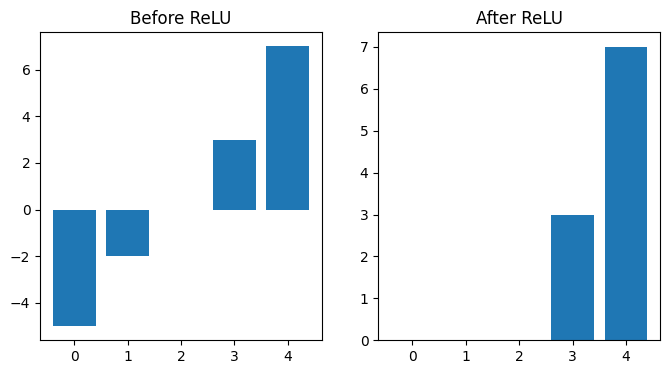

In [6]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)

plt.bar(
    range(len(sample)),
    sample
)

plt.title("Before ReLU")

plt.subplot(1,2,2)

plt.bar(
    range(len(output)),
    output
)

plt.title("After ReLU")

plt.show()

Matrix example

In [7]:
matrix = np.array(
[
    [-5,-1,3],
    [2,-4,7],
    [-3,5,-2]
]
)

print(matrix)

[[-5 -1  3]
 [ 2 -4  7]
 [-3  5 -2]]


In [8]:
relu_output = relu.forward(matrix)

print(relu_output)

[[0 0 3]
 [2 0 7]
 [0 5 0]]


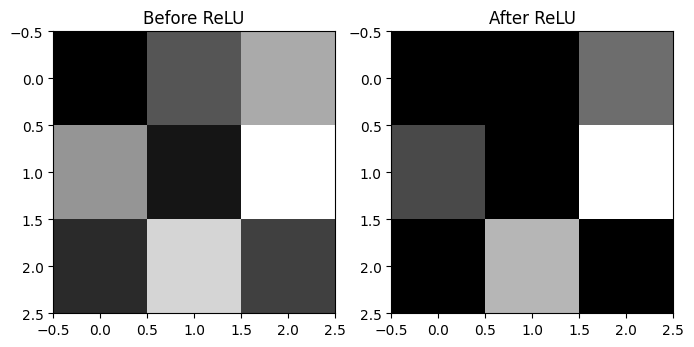

In [9]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(8,4)
)

ax[0].imshow(
    matrix,
    cmap="gray"
)

ax[0].set_title(
    "Before ReLU"
)

ax[1].imshow(
    relu_output,
    cmap="gray"
)

ax[1].set_title(
    "After ReLU"
)

plt.show()

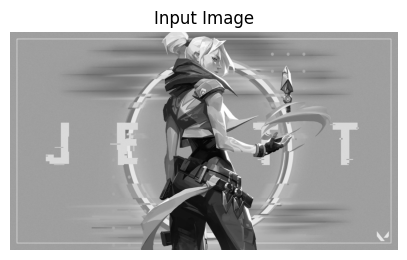

In [10]:
# ReLU on Real Image Feature Maps

image = load_image(
    "../data/sample.jpg",
    grayscale=True
)

show_image(
    image,
    "Input Image"
)

In [11]:
conv = Convolution2D(
    in_channels=1,
    out_channels=4,
    kernel_size=3,
    padding=1
)

feature_maps = conv.forward(image)

print(
    feature_maps.shape
)

(4, 1080, 1920)


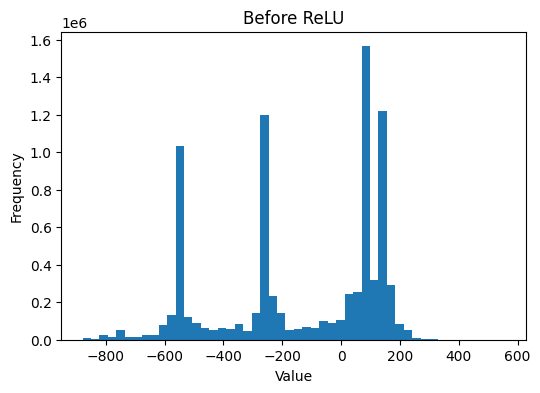

In [12]:
plot_histogram(
    feature_maps,
    title="Before ReLU"
)

In [13]:
relu_maps = relu.forward(
    feature_maps
)

print(
    relu_maps.shape
)

(4, 1080, 1920)


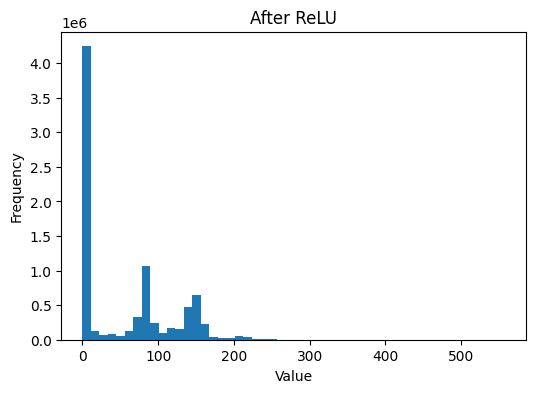

In [14]:
plot_histogram(
    relu_maps,
    title="After ReLU"
)

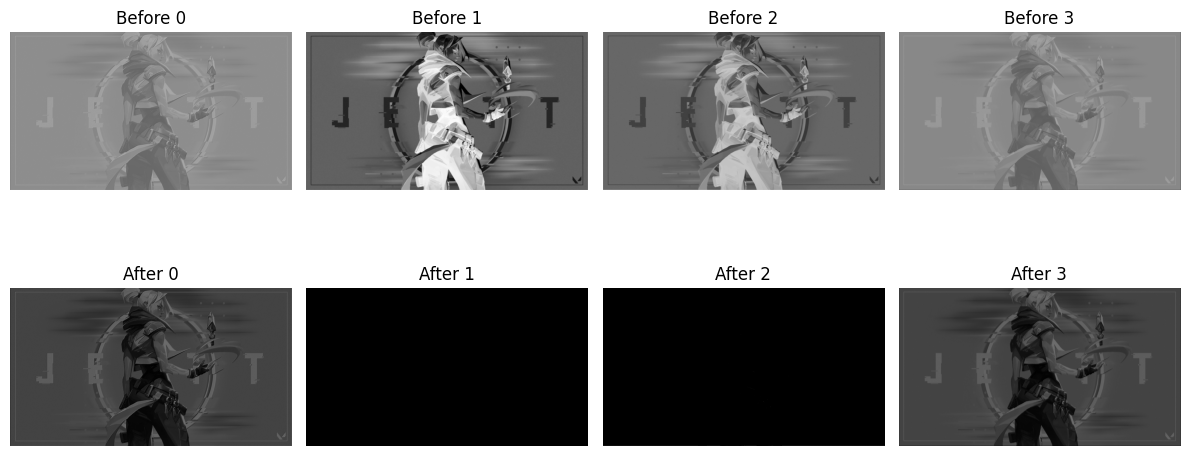

In [15]:
# Part 5 Feature Map Visualization

fig, ax = plt.subplots(
    2,
    4,
    figsize=(12,6)
)

for i in range(4):

    ax[0,i].imshow(
        feature_maps[i],
        cmap="gray"
    )

    ax[0,i].set_title(
        f"Before {i}"
    )

    ax[0,i].axis("off")

    ax[1,i].imshow(
        relu_maps[i],
        cmap="gray"
    )

    ax[1,i].set_title(
        f"After {i}"
    )

    ax[1,i].axis("off")

plt.tight_layout()

plt.show()

In [16]:
# Part 6 Why ReLU Works

# ReLU creates sparsity.

# Negative activations
# become zero.

# This allows CNN
# to focus on important
# features only.


# Tính sparsity

zeros = np.sum(
    relu_maps == 0
)

total = relu_maps.size

print(
    f"Zero Values: {zeros}"
)

print(
    f"Sparsity: {100*zeros/total:.2f}%"
)

Zero Values: 4170783
Sparsity: 50.28%


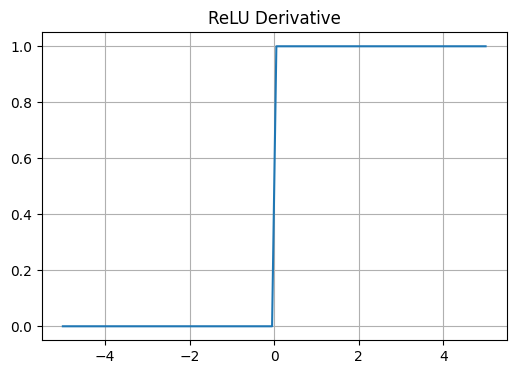

In [17]:
# ReLU Backward

x = np.linspace(-5,5,100)

grad = np.where(
    x > 0,
    1,
    0
)

plt.figure(figsize=(6,4))

plt.plot(x,grad)

plt.title(
    "ReLU Derivative"
)

plt.grid(True)

plt.show()

In [18]:
x = np.array([
    -3,
    4,
    -2,
    7
])

grad_output = np.ones_like(x)

grad_input = np.where(
    x > 0,
    grad_output,
    0
)

print("Input:", x)

print(
    "Gradient:",
    grad_input
)

Input: [-3  4 -2  7]
Gradient: [0 1 0 1]


In [19]:
print(
    "Before ReLU"
)

print(
    "Min:",
    feature_maps.min()
)

print(
    "Max:",
    feature_maps.max()
)

print(
    "\nAfter ReLU"
)

print(
    "Min:",
    relu_maps.min()
)

print(
    "Max:",
    relu_maps.max()
)

Before ReLU
Min: -878.7523082824866
Max: 558.2658747149198

After ReLU
Min: 0.0
Max: 558.2658747149198
